# Data analysis demo

A realistic pandas + matplotlib notebook, kept small enough to read at a glance.
Every output below is checked in, so this renders fully **without a running
kernel** — useful for demos, screenshots, and for exercising the output-rendering
paths when no Python runtime is configured.

What to look at:

- DataFrame repr as a real HTML table (not just `text/plain`)
- An inline matplotlib PNG
- A `.style` gradient table, which is HTML + CSS in one output
- How `jupyter.get_notebook_projection` compresses all of it for the agent

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fixed seed: the checked-in outputs should be reproducible.
rng = np.random.default_rng(20260811)
pd.set_option("display.precision", 2)

## A small deployment dataset

Six weeks of build and deploy telemetry across three services.

In [2]:
services = ["api-gateway", "search-indexer", "billing-worker"]
weeks = pd.date_range("2026-06-29", periods=6, freq="W-MON")

frame = pd.DataFrame(
    [
        {
            "week": week,
            "service": service,
            "deploys": int(rng.integers(4, 19)),
            "build_minutes": round(float(rng.normal(11, 2.5)), 2),
            "failure_rate": round(float(rng.beta(2, 28)), 4),
        }
        for week in weeks
        for service in services
    ]
)
frame.head(9)

,week,service,deploys,build_minutes,failure_rate
0,2026-06-29,api-gateway,11,12.12,0.10
1,2026-06-29,search-indexer,8,7.99,0.04
2,2026-06-29,billing-worker,5,10.27,0.07
3,2026-07-06,api-gateway,14,10.13,0.08
4,2026-07-06,search-indexer,16,13.07,0.05
5,2026-07-06,billing-worker,17,5.37,0.05
6,2026-07-13,api-gateway,4,8.85,0.02
7,2026-07-13,search-indexer,7,13.17,0.06
8,2026-07-13,billing-worker,4,7.48,0.16


## Aggregate by service

`groupby` + `agg` gives the summary table most of these notebooks end up wanting.

In [3]:
summary = (
    frame.groupby("service")
    .agg(
        deploys=("deploys", "sum"),
        avg_build_min=("build_minutes", "mean"),
        worst_build_min=("build_minutes", "max"),
        avg_failure_rate=("failure_rate", "mean"),
    )
    .sort_values("deploys", ascending=False)
)
summary

,deploys,avg_build_min,worst_build_min,avg_failure_rate
service,,,,
billing-worker,58,10.22,14.38,0.06
search-indexer,53,10.51,13.17,0.06
api-gateway,51,9.81,12.12,0.06


In [4]:
frame[["deploys", "build_minutes", "failure_rate"]].describe()

,deploys,build_minutes,failure_rate
count,18.00,18.00,1.80e+01
mean,9.00,10.18,6.05e-02
std,4.52,2.51,3.63e-02
min,4.00,5.37,5.20e-03
25%,5.00,8.21,4.47e-02
50%,7.50,10.27,5.29e-02
75%,13.50,11.94,8.03e-02
max,17.00,14.38,1.64e-01


## Plot the trend

A single inline figure. The PNG is stored in the notebook, which is exactly the
kind of payload `jupyter.get_notebook_projection` replaces with a placeholder so
it never lands in an agent's context window — use
`jupyter.get_cell_output(includeImages=true)` to actually look at it.

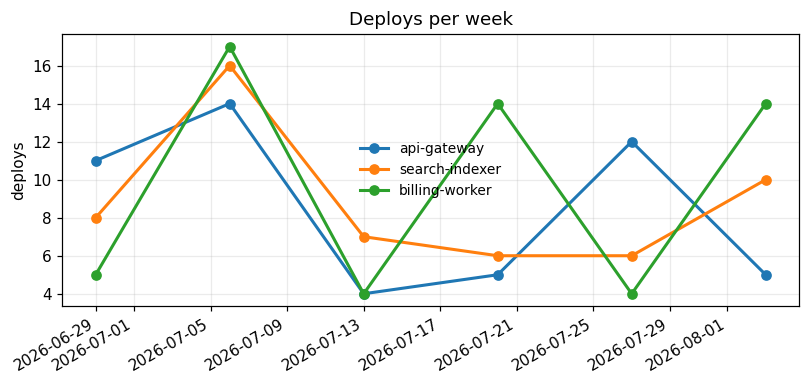

In [5]:
pivot = frame.pivot_table(index="week", columns="service", values="deploys")

fig, ax = plt.subplots(figsize=(7.5, 3.6), dpi=110)
for service in services:
    ax.plot(pivot.index, pivot[service], marker="o", linewidth=2, label=service)

ax.set_title("Deploys per week")
ax.set_ylabel("deploys")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9)
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

## Styled output

`DataFrame.style` emits HTML with scoped CSS — a good check that the renderer is
not stripping style blocks.

In [6]:
(
    summary.style
    .background_gradient(cmap="Blues", subset=["deploys"])
    .format({"avg_build_min": "{:.2f}", "worst_build_min": "{:.2f}", "avg_failure_rate": "{:.2%}"})
    .set_caption("Deploy summary by service")
)

,deploys,avg_build_min,worst_build_min,avg_failure_rate
service,,,,
billing-worker,58,10.22,14.38,6.32%
search-indexer,53,10.51,13.17,5.61%
api-gateway,51,9.81,12.12,6.23%


## For the agent

Useful things to try against this notebook:

- `jupyter.get_notebook_projection` — every cell source verbatim, outputs reduced
  to `[image/png hidden: N chars]` style placeholders.
- `jupyter.list_variables` / `jupyter.inspect_variable` on `frame` or `summary`.
- `jupyter.preview_dataframe` on `frame` for a compact tabular view.
- `jupyter.get_cell_output` with `includeImages=true` on the plot cell to write
  the PNG to disk and actually read it.